# B+ → π+ π+ π−: QMI / isobar closure without CP

This notebook removes the CP fit completely and asks a simpler question:

> Can a one-dimensional QMI S-wave recover an isobaric S-wave truth?

The toy is generated from the same isobaric model used in the CP closure, but
with **no charge dependence**. The scalar truth contains only the paper
$\sigma$ pole. In the fit the $\sigma$ is replaced by a cubic QMI.

For this first diagnostic:

- only one $B^+$ sample is generated and fitted;
- the $\rho(770)$ coefficient is the global amplitude reference, fixed to $1+0i$;
- the global QMI coefficient is fixed to $1+0i$;
- **all QMI knots are free**, including the first knot;
- the QMI fit does **not** start from the isobaric truth: every knot starts at
  magnitude 1 and phase 0;
- higher-wave coefficients start at their generated values but remain free
  except for the $\rho(770)$ reference;
- no post-fit scale factor or phase shift is applied in the S-wave closure plots.

If this test fails, the problem is inside the QMI / dynamic-cache /
normalization / single-sample `FitSession` chain rather than the CP machinery.


In [1]:
import numpy as np
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dataclasses import dataclass

from dalitzplotfitter import (
    DecayChannel,
    DecayModel,
    FitSession,
    GounarisSakurai,
    Parameter,
    QMI,
    RealImag,
    RelativisticBreitWigner,
    Resonance,
    enable_x64,
    generate_signal_toy,
)

enable_x64()

SEED = 20260905
N_EVENTS = 250_000
NORMALIZATION_RESOLUTION = 1500
QMI_INTERPOLATION = "linear"
TOY_METHOD = "accept-reject"

channel = DecayChannel("B+", ("pi+", "pi+", "pi-"))
M_PI = float(channel.daughter_masses[0])

print("Toy size:", N_EVENTS)
print("Normalization resolution:", NORMALIZATION_RESOLUTION)
print("QMI interpolation:", QMI_INTERPOLATION)
print("Toy method:", TOY_METHOD)


Toy size: 250000
Normalization resolution: 1500
QMI interpolation: linear


## Isobaric truth

We keep the CP-averaged Cartesian coefficients from the previous example and
drop all `dx/dy` terms. Thus each component has a single coefficient

\[
c_j = x_j + i y_j.
\]

The $\rho(770)$ is the amplitude reference.


In [2]:
TRUTH_COEFFICIENTS = {
    "rho770":    dict(x= 1.000, y= 0.000),
    "omega782":  dict(x= 0.091, y=-0.007),
    "f2_1270":   dict(x= 0.291, y= 0.204),
    "rho1450":   dict(x=-0.223, y= 0.191),
    "rho3_1690": dict(x= 0.073, y=-0.045),
    "sigma":     dict(x=-0.485, y= 0.284),
}

def truth_coefficient(name):
    p = TRUTH_COEFFICIENTS[name]
    return RealImag(p["x"], p["y"])


In [3]:
@dataclass(frozen=True)
class PaperSigmaPole:
    # LHCb Eq. (16): A_sigma(m) = 1 / (s_sigma - m^2)
    def __call__(self, mass, context):
        m = jnp.asarray(mass)
        pole = jnp.asarray(context.pole_mass) - 1j * jnp.asarray(context.pole_width)
        s_sigma = pole**2
        return 1.0 / (s_sigma - m**2)


def generator_components():
    return [
        Resonance(
            "rho770", (0, 2), truth_coefficient("rho770"),
            mass=0.7708, width=0.1534, spin=1,
            lineshape=GounarisSakurai(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "omega782", (0, 2), truth_coefficient("omega782"),
            mass=0.78265, width=0.00849, spin=1,
            lineshape=RelativisticBreitWigner(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "f2_1270", (0, 2), truth_coefficient("f2_1270"),
            mass=1.2755, width=0.1867, spin=2,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho1450", (0, 2), truth_coefficient("rho1450"),
            mass=1.465, width=0.400, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho3_1690", (0, 2), truth_coefficient("rho3_1690"),
            mass=1.6888, width=0.161, spin=3,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "sigma", (0, 2), truth_coefficient("sigma"),
            mass=0.563, width=0.350, spin=0,
            lineshape=PaperSigmaPole(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
    ]


generator = DecayModel(
    channel,
    generator_components(),
    normalize_components=True,
    normalization_method="gauss-legendre",
    #normalization_resolution=NORMALIZATION_RESOLUTION,
    #normalization_pair=(0, 2),
)

print("Generator normalization points:", generator.normalization_sample.size)


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
Generator normalization points: 2080469


## Generate the isobaric toy

The toy is generated with the exact accept-reject reference sampler. The
candidate pools are evaluated directly in Dalitz invariants; four-momenta are
not retained because this closure uses only $s_{12}$, $s_{13}$ and $s_{23}$.


In [ ]:
toy = generate_signal_toy(
    generator,
    N_EVENTS,
    seed=SEED,
    method=TOY_METHOD,
    include_momenta=False,
)

print("Generated events:", toy.size)
print("Toy method:", TOY_METHOD)
print("weights:", np.unique(np.asarray(toy.weights)))


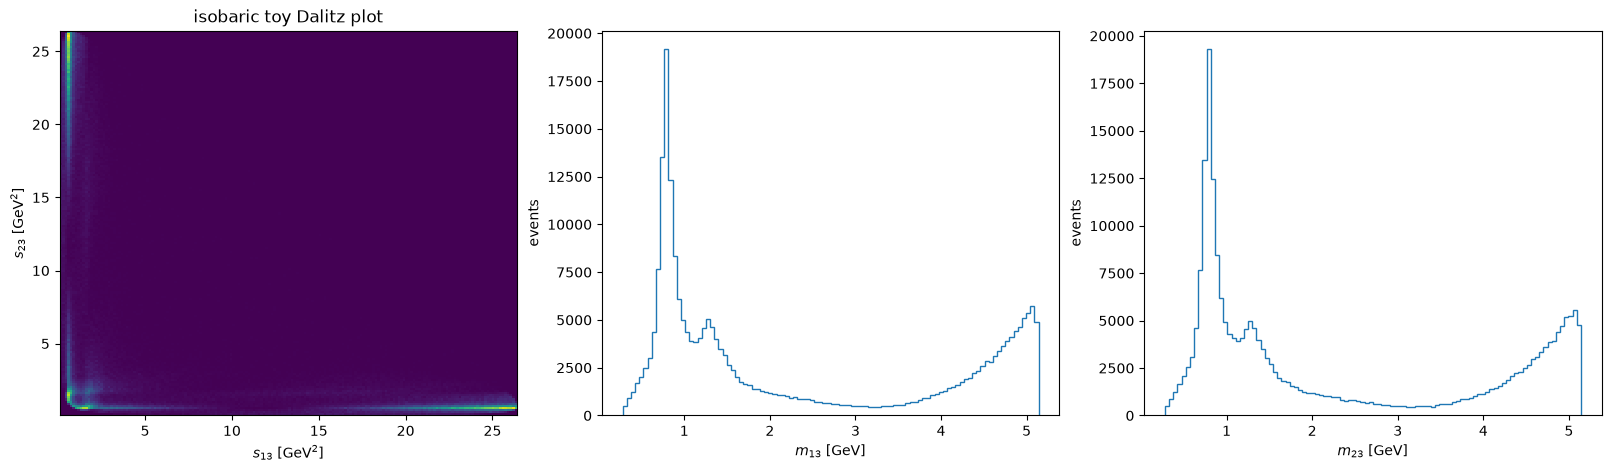

In [5]:
# Toy Dalitz plot and invariant-mass projections before any fit.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

axes[0].hist2d(
    np.asarray(toy.s13),
    np.asarray(toy.s23),
    bins=180,
)
axes[0].set_xlabel(r"$s_{13}$ [GeV$^2$]")
axes[0].set_ylabel(r"$s_{23}$ [GeV$^2$]")
axes[0].set_title("isobaric toy Dalitz plot")

for ax, values, label in [
    (axes[1], np.sqrt(np.asarray(toy.s13)), r"$m_{13}$"),
    (axes[2], np.sqrt(np.asarray(toy.s23)), r"$m_{23}$"),
]:
    ax.hist(values, bins=100, histtype="step")
    ax.set_xlabel(label + " [GeV]")
    ax.set_ylabel("events")

plt.show()


## Build truth-informed QMI knots

The physical scalar amplitude that the QMI must reproduce is not the bare
$\sigma$ lineshape. It includes the generated complex coefficient and the
component normalization convention used by the `DecayModel`:

\[
A_S^{\rm truth}(m)
=
c_\sigma\,N_\sigma\,A_\sigma(m).
\]

We evaluate this physical amplitude at the QMI knots and use its magnitude and
an **unwrapped** phase as the starting point.

The first and last knots are placed at the exact kinematic boundaries of the
$\pi^+\pi^-$ pair so the QMI does not rely on endpoint clamping inside the
physical region.


In [6]:
def component_by_name(model, name):
    for component in model.amplitude_model.components:
        if component.name == name:
            return component
    raise KeyError(name)


def scalar_truth_single_pair(masses):
    comp = component_by_name(generator, "sigma")
    coefficient = complex(np.asarray(comp.coefficient.value({})))
    scale = float(np.asarray(generator._component_scale(comp, {})))
    lineshape = comp.function.lineshape
    context = comp.function.context.resolve({})
    return coefficient * scale * np.asarray(
        lineshape(jnp.asarray(masses), context)
    )


PAIR_THRESHOLD = channel.daughter_masses[0] + channel.daughter_masses[2]
PAIR_MAXIMUM = channel.parent_mass - channel.daughter_masses[1]

QMI_KNOTS = (
    float(PAIR_THRESHOLD),
    0.400, 0.510, 0.630, 0.700, 0.770, 0.840, 0.900,
    0.990, 1.110, 1.210, 1.300, 1.400, 1.560, 1.740, 2.000,
    2.500,3.000,     3.500,
    float(PAIR_MAXIMUM),
)

truth_knot_amplitudes = scalar_truth_single_pair(np.asarray(QMI_KNOTS))
truth_knot_magnitudes = np.abs(truth_knot_amplitudes)
truth_knot_phases = np.unwrap(np.angle(truth_knot_amplitudes))

print("QMI knots:", len(QMI_KNOTS))
print("physical range:", QMI_KNOTS[0], "to", QMI_KNOTS[-1], "GeV")
print()
print(f"{'m [GeV]':>9s} {'|A_truth|':>12s} {'phase truth [rad]':>18s}")
for m, mag, phase in zip(QMI_KNOTS, truth_knot_magnitudes, truth_knot_phases):
    print(f"{m:9.4f} {mag:12.6f} {phase:18.6f}")


QMI knots: 20
physical range: 0.27914078000000003 to 5.139839609999999 GeV

  m [GeV]    |A_truth|  phase truth [rad]
   0.2791     0.086494          -2.388076
   0.4000     0.089854          -2.187776
   0.5100     0.088972          -1.935516
   0.6300     0.080232          -1.626025
   0.7000     0.072161          -1.457106
   0.7700     0.063429          -1.309673
   0.8400     0.055075          -1.186568
   0.9000     0.048635          -1.099237
   0.9900     0.040443          -0.994694
   1.1100     0.032025          -0.892718
   1.2100     0.026739          -0.830715
   1.3000     0.022984          -0.787400
   1.4000     0.019650          -0.749358
   1.5600     0.015635          -0.703961
   1.7400     0.012427          -0.667957
   2.0000     0.009291          -0.632931
   2.5000     0.005858          -0.594729
   3.0000     0.004033          -0.574466
   3.5000     0.002947          -0.562418
   5.1398     0.001355          -0.544767


### Representation-only check

Before fitting anything, construct a numerical QMI directly from the truth
values at the knots. This is only a representation diagnostic: it isolates the
QMI interpolation from the likelihood and minimizer. These truth knot values
are **not** used as the fit starting point.


representation-only relative complex RMS = 8.149641e-03


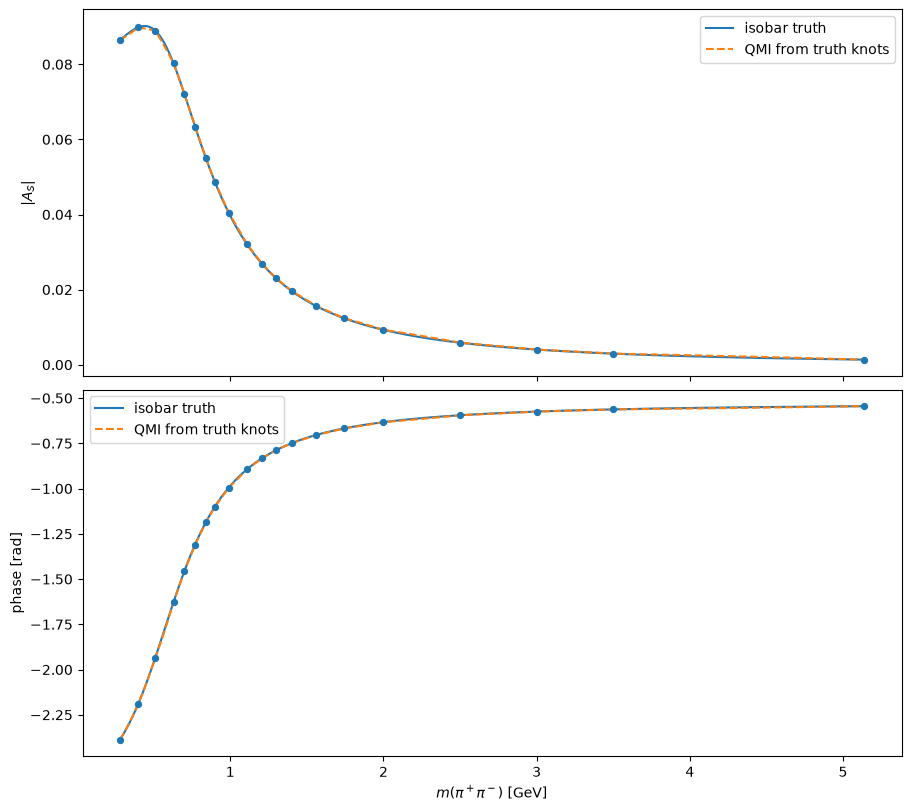

In [7]:
truth_seed_qmi = QMI(
    knots=QMI_KNOTS,
    magnitudes=tuple(float(v) for v in truth_knot_magnitudes),
    phases=tuple(float(v) for v in truth_knot_phases),
    interpolation=QMI_INTERPOLATION,
)

qmi_context = component_by_name(generator, "sigma").function.context.resolve({})

mass_scan = np.linspace(QMI_KNOTS[0], QMI_KNOTS[-1], 3000)
truth_scan = scalar_truth_single_pair(mass_scan)
seed_scan = np.asarray(
    truth_seed_qmi(jnp.asarray(mass_scan), qmi_context)
)

relative_rms = np.sqrt(
    np.mean(np.abs(seed_scan - truth_scan)**2)
    / np.mean(np.abs(truth_scan)**2)
)

print(f"representation-only relative complex RMS = {relative_rms:.6e}")

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, constrained_layout=True)

axes[0].plot(mass_scan, np.abs(truth_scan), label="isobar truth")
axes[0].plot(mass_scan, np.abs(seed_scan), "--", label="QMI from truth knots")
axes[0].scatter(QMI_KNOTS, truth_knot_magnitudes, s=18, zorder=3)
axes[0].set_ylabel(r"$|A_S|$")
axes[0].legend()

axes[1].plot(mass_scan, np.unwrap(np.angle(truth_scan)), label="isobar truth")
axes[1].plot(mass_scan, np.unwrap(np.angle(seed_scan)), "--", label="QMI from truth knots")
axes[1].scatter(QMI_KNOTS, truth_knot_phases, s=18, zorder=3)
axes[1].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
axes[1].set_ylabel("phase [rad]")
axes[1].legend()

plt.show()


## Fit model

All QMI knots are free. The global QMI coefficient is fixed to $1+0i$ so the
knot values themselves carry the physical S-wave magnitude and phase.

The fit deliberately starts **away from the truth**:

- every QMI magnitude starts at `1.0`;
- every QMI phase starts at `0.0`;
- higher-wave coefficients start at their generated values and remain free,
  except for the fixed $\rho(770)$ reference.

The truth-informed knot values constructed above are used only to quantify how
well the chosen QMI interpolation can represent the isobaric $\sigma$ shape.


In [ ]:
def qmi_parameters():
    magnitudes = []
    phases = []
    for i, (mag0, phase0) in enumerate(
        zip(truth_knot_magnitudes, truth_knot_phases)
    ):
        magnitudes.append(
            Parameter.dynamics(
                f"S_QMI.mag[{i}]",
                float(1.0),
                owner="S_QMI",
                bounds=(0.0, 10.0),
                step=0.01,
            )
        )
        phases.append(
            Parameter.dynamics(
                f"S_QMI.phase[{i}]",
                float(0.),
                owner="S_QMI",
                bounds=(-8.0*np.pi, 8.0*np.pi),
                step=0.02,
            )
        )
    return tuple(magnitudes), tuple(phases)


qmi_magnitudes, qmi_phases = qmi_parameters()
print("QMI fit start: all magnitudes = 1.0, all phases = 0.0")

qmi = QMI(
    QMI_KNOTS,
    qmi_magnitudes,
    qmi_phases,
    interpolation=QMI_INTERPOLATION,
)


def floating_coefficient(name):
    truth = TRUTH_COEFFICIENTS[name]
    reference = name == "rho770"
    x = Parameter.coefficient(
        f"{name}.x",
        truth["x"],
        owner=name,
        fixed=reference,
        step=0.01,
    )
    y = Parameter.coefficient(
        f"{name}.y",
        truth["y"],
        owner=name,
        fixed=reference,
        step=0.01,
    )
    return RealImag(x, y)


def fit_components():
    return [
        Resonance(
            "rho770", (0, 2), floating_coefficient("rho770"),
            mass=0.7708, width=0.1534, spin=1,
            lineshape=GounarisSakurai(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "omega782", (0, 2), floating_coefficient("omega782"),
            mass=0.78265, width=0.00849, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "f2_1270", (0, 2), floating_coefficient("f2_1270"),
            mass=1.2755, width=0.1867, spin=2,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho1450", (0, 2), floating_coefficient("rho1450"),
            mass=1.465, width=0.400, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho3_1690", (0, 2), floating_coefficient("rho3_1690"),
            mass=1.6888, width=0.161, spin=3,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "S_QMI", (0, 2), RealImag(1.0, 0.0),
            mass=1.0, width=0.1, spin=0,
            lineshape=qmi,
            normalize_component=False,
            resonance_radius=4.0, parent_radius=4.0,
        ),
    ]


fit_model = DecayModel(
    channel,
    fit_components(),
    normalize_components=True,
    normalization_method="gauss-legendre"
    # normalization_method="square-dalitz",
    # normalization_resolution=NORMALIZATION_RESOLUTION,
    # normalization_pair=(0, 2),
)

session = FitSession(fit_model, toy)

print("Number of fit parameters:", len(session.parameters))
print("Free parameters:", sum(not p.fixed for p in session.parameters))
print("rho770 fixed reference: 1+0i")
print("S_QMI global coefficient: fixed 1+0i")
print("all QMI knots: free")


## Baseline fit

The QMI starts from a flat configuration, with all knot magnitudes equal to 1
and all knot phases equal to 0. This is therefore a genuine closure test of the
minimizer and QMI likelihood rather than a fit initialized on the truth branch.

Higher-wave coefficients still start at their generated values, with the
$\rho(770)$ fixed as the global amplitude reference.


In [ ]:
start_values = {
    parameter.name: float(parameter.value)
    for parameter in session.parameters
    if not parameter.fixed
}

result = session.fit(
    start_values=start_values,
    simplex=False,
    strategy=1,
    hesse=False,
    tolerance=1e-4,
    verbose=3,
)

fit_values = session.print_result(result)

print()
print("valid:", bool(result.valid))
print("EDM:", float(result.fmin.edm))
print("nfcn:", int(result.nfcn))


INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
[Minimizer] single fit with 48 free parameters (simplex=False, strategy=1, hesse=False, ncall=None, tolerance=0.0001)
I MnSeedGenerator Using analytical (external) gradient calculator but cannot compute G2 - use then numerical gradient for G2
I MnSeedGenerator Computing seed using NumericalGradient calculator
I MnSeedGenerator Evaluated function and gradient in 19.4091 s
I MnSeedGenerator Initial state: FCN =       1487732.898 Edm =   1.700744123e+10 NCalls =    171
I NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative


## Direct S-wave closure

No arbitrary scaling and no phase offset are applied below.


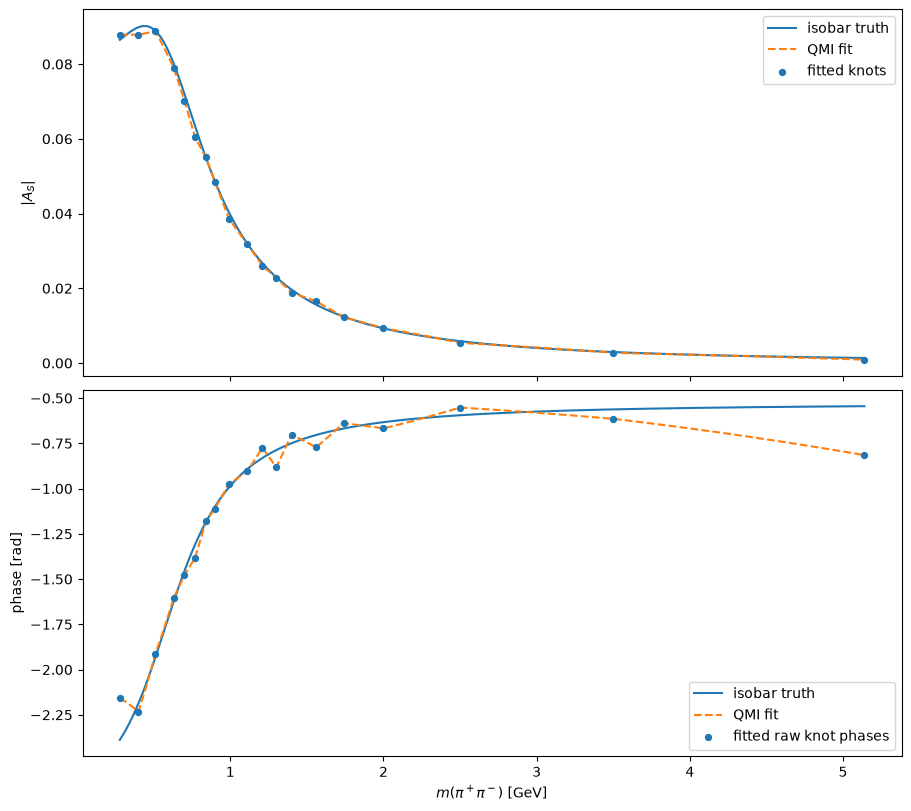

post-fit relative complex RMS = 6.707001e-02


In [ ]:
def resolved_qmi(qmi_model, values):
    return QMI(
        qmi_model.knots,
        tuple(
            float(p.resolve(values)) if hasattr(p, "resolve") else float(p)
            for p in qmi_model.magnitudes
        ),
        tuple(
            float(p.resolve(values)) if hasattr(p, "resolve") else float(p)
            for p in qmi_model.phases
        ),
        interpolation=qmi_model.interpolation,
    )


def fitted_qmi_single_pair(masses, values):
    comp = component_by_name(fit_model, "S_QMI")
    context = comp.function.context.resolve(values)
    dynamics = np.asarray(
        resolved_qmi(qmi, values)(jnp.asarray(masses), context)
    )
    coefficient = complex(np.asarray(comp.coefficient.value(values)))
    scale = float(np.asarray(fit_model._component_scale(comp, values)))
    return coefficient * scale * dynamics


fit_scan = fitted_qmi_single_pair(mass_scan, fit_values)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True, constrained_layout=True)

axes[0].plot(mass_scan, np.abs(truth_scan), label="isobar truth")
axes[0].plot(mass_scan, np.abs(fit_scan), "--", label="QMI fit")
axes[0].scatter(
    QMI_KNOTS,
    [float(p.resolve(fit_values)) for p in qmi_magnitudes],
    s=18,
    zorder=3,
    label="fitted knots",
)
axes[0].set_ylabel(r"$|A_S|$")
axes[0].legend()

axes[1].plot(
    mass_scan,
    np.unwrap(np.angle(truth_scan)),
    label="isobar truth",
)
axes[1].plot(
    mass_scan,
    np.unwrap(np.angle(fit_scan)),
    "--",
    label="QMI fit",
)
axes[1].scatter(
    QMI_KNOTS,
    [float(p.resolve(fit_values)) for p in qmi_phases],
    s=18,
    zorder=3,
    label="fitted raw knot phases",
)
axes[1].set_xlabel(r"$m(\pi^+\pi^-)$ [GeV]")
axes[1].set_ylabel("phase [rad]")
axes[1].legend()

plt.show()

complex_rms = np.sqrt(
    np.mean(np.abs(fit_scan - truth_scan)**2)
    / np.mean(np.abs(truth_scan)**2)
)
print(f"post-fit relative complex RMS = {complex_rms:.6e}")


## Knot-by-knot closure


In [ ]:
rows = []
for i, (mass, mag_par, phase_par, mag_truth, phase_truth) in enumerate(
    zip(
        QMI_KNOTS,
        qmi_magnitudes,
        qmi_phases,
        truth_knot_magnitudes,
        truth_knot_phases,
    )
):
    mag_fit = float(mag_par.resolve(fit_values))
    phase_fit = float(phase_par.resolve(fit_values))
    mag_err = float(result.errors[mag_par.name])
    phase_err = float(result.errors[phase_par.name])
    rows.append({
        "knot": i,
        "m [GeV]": mass,
        "mag truth": mag_truth,
        "mag fit": mag_fit,
        "mag err": mag_err,
        "mag pull": (mag_fit - mag_truth) / mag_err if mag_err > 0 else np.nan,
        "phase truth": phase_truth,
        "phase fit": phase_fit,
        "phase err": phase_err,
        "phase pull": (phase_fit - phase_truth) / phase_err if phase_err > 0 else np.nan,
    })

qmi_table = pd.DataFrame(rows)
display(qmi_table)


,knot,m [GeV],mag truth,mag fit,mag err,mag pull,phase truth,phase fit,phase err,phase pull
0,0,0.279141,0.086494,0.087814,0.002077,0.635855,-2.388076,-2.157209,0.155176,1.487773
1,1,0.400000,0.089854,0.087882,0.001027,-1.919717,-2.187776,-2.233109,0.045408,-0.998335
2,2,0.510000,0.088972,0.088787,0.000884,-0.208251,-1.935516,-1.913731,0.022256,0.978843
3,3,0.630000,0.080232,0.079055,0.001016,-1.158822,-1.626025,-1.604808,0.016122,1.316030
4,4,0.700000,0.072161,0.070238,0.001267,-1.518041,-1.457106,-1.478886,0.019943,-1.092097
5,5,0.770000,0.063429,0.060389,0.000880,-3.456837,-1.309673,-1.382410,0.030062,-2.419575
6,6,0.840000,0.055075,0.055020,0.000992,-0.055385,-1.186568,-1.181222,0.029537,0.180996
7,7,0.900000,0.048635,0.048449,0.000919,-0.202212,-1.099237,-1.110214,0.023552,-0.466044
8,8,0.990000,0.040443,0.038623,0.000752,-2.420184,-0.994694,-0.975880,0.021705,0.866825
9,9,1.110000,0.032025,0.031778,0.000705,-0.351349,-0.892718,-0.904223,0.022714,-0.506523


## Higher-wave closure

These plots also use the absolute fitted normalization. There is **no**
`truth.sum()/fit.sum()` rescaling.


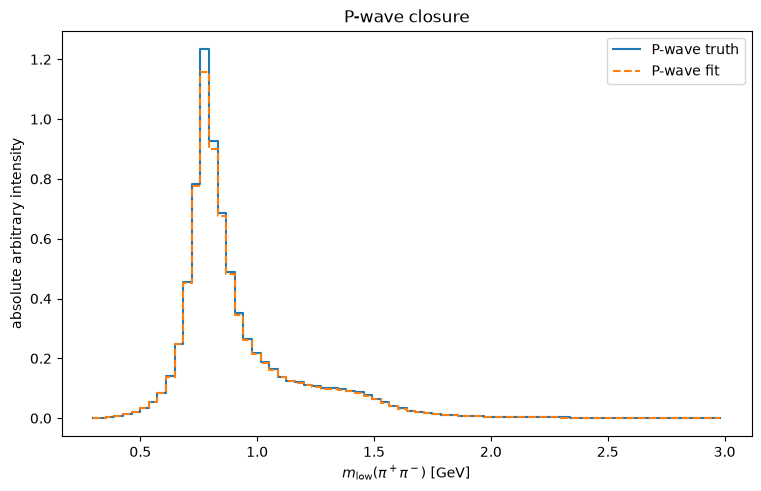

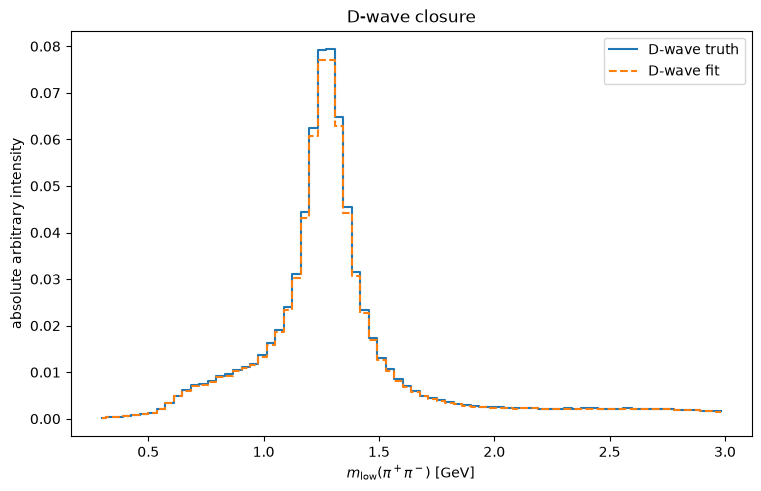

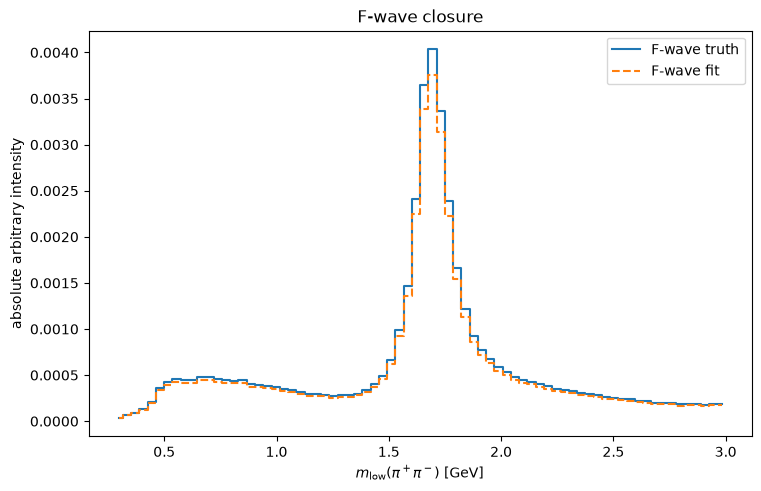

In [ ]:
def component_amplitude(model, name, data, values):
    comp = component_by_name(model, name)
    dynamics = jnp.asarray(comp.function(data, values))
    coefficient = jnp.asarray(comp.coefficient.value(values))
    scale = model._component_scale(comp, values)
    return coefficient * scale * dynamics


def coherent_group(model, names, data, values):
    total = 0.0j
    for name in names:
        total = total + component_amplitude(model, name, data, values)
    return jnp.asarray(total)


WAVES = {
    "P": ("rho770", "omega782", "rho1450"),
    "D": ("f2_1270",),
    "F": ("rho3_1690",),
}

validation = generator.generate_phase_space(700_000, seed=SEED + 501)

def min_pipi_mass(sample):
    return np.sqrt(
        np.minimum(np.asarray(sample.s13), np.asarray(sample.s23))
    )

def binned_wave_intensity(sample, generator_model, fitted_model, names, fit_values, bins):
    data = sample.as_dict()
    truth_amp = np.asarray(coherent_group(generator_model, names, data, {}))
    fit_amp = np.asarray(coherent_group(fitted_model, names, data, fit_values))
    mass = min_pipi_mass(sample)
    weights = np.asarray(sample.weights)
    truth_hist, edges = np.histogram(
        mass, bins=bins, weights=weights*np.abs(truth_amp)**2
    )
    fit_hist, _ = np.histogram(
        mass, bins=edges, weights=weights*np.abs(fit_amp)**2
    )
    centers = 0.5*(edges[:-1] + edges[1:])
    return centers, truth_hist, fit_hist

bins = np.linspace(2*M_PI, 3.0, 75)

for wave, names in WAVES.items():
    centers, truth_hist, fit_hist = binned_wave_intensity(
        validation, generator, fit_model, names, fit_values, bins
    )
    fig, ax = plt.subplots(figsize=(7.5, 4.8), constrained_layout=True)
    ax.step(centers, truth_hist, where="mid", label=f"{wave}-wave truth")
    ax.step(centers, fit_hist, where="mid", linestyle="--", label=f"{wave}-wave fit")
    ax.set_xlabel(r"$m_{\rm low}(\pi^+\pi^-)$ [GeV]")
    ax.set_ylabel("absolute arbitrary intensity")
    ax.set_title(f"{wave}-wave closure")
    ax.legend()
    plt.show()


## Higher-wave coefficient pulls


In [ ]:
rows = []
for name in ("rho770", "omega782", "rho1450", "f2_1270", "rho3_1690"):
    truth = TRUTH_COEFFICIENTS[name]
    for field in ("x", "y"):
        pname = f"{name}.{field}"
        parameter = next(
            (p for p in session.parameters if p.name == pname),
            None,
        )
        if parameter is None:
            continue
        fitted = fit_values[pname]
        error = 0.0 if parameter.fixed else float(result.errors[pname])
        pull = (
            np.nan
            if error == 0.0
            else (fitted - truth[field]) / error
        )
        rows.append({
            "component": name,
            "parameter": field,
            "truth": truth[field],
            "fit": fitted,
            "error": error,
            "pull": pull,
            "fixed": parameter.fixed,
        })

coefficient_table = pd.DataFrame(rows)
display(coefficient_table)


,component,parameter,truth,fit,error,pull,fixed
0,rho770,x,1.000,1.000000,0.000000,NaN,True
1,rho770,y,0.000,0.000000,0.000000,NaN,True
2,omega782,x,0.091,0.068108,0.002114,-10.829974,False
3,omega782,y,-0.007,-0.005172,0.002236,0.817681,False
4,rho1450,x,-0.223,-0.220914,0.004137,0.504262,False
5,rho1450,y,0.191,0.186208,0.003849,-1.244988,False
6,f2_1270,x,0.291,0.287905,0.003108,-0.995780,False
7,f2_1270,y,0.204,0.199638,0.003227,-1.351727,False
8,rho3_1690,x,0.073,0.069313,0.002685,-1.373161,False
9,rho3_1690,y,-0.045,-0.045185,0.003014,-0.061460,False


## Fit projections


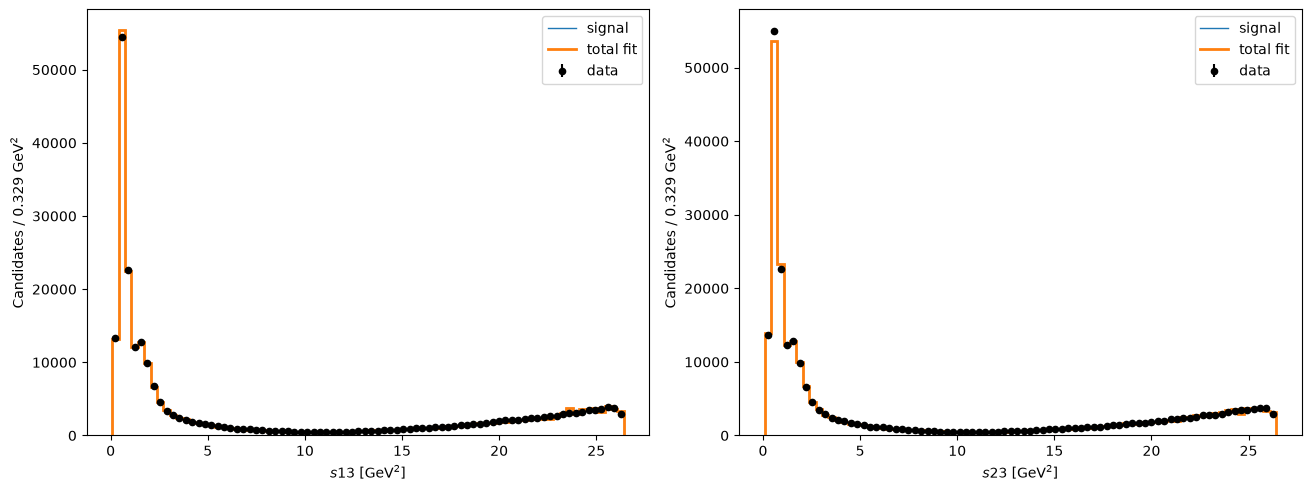

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

session.plot_projection(
    result,
    "s13",
    bins=80,
    projection_size=300_000,
    projection_seed=SEED + 700,
    ax=axes[0],
)
session.plot_projection(
    result,
    "s23",
    bins=80,
    projection_size=300_000,
    projection_seed=SEED + 701,
    ax=axes[1],
)

plt.show()


## Optional diagnostics if the baseline closure fails

Run these only if the direct S-wave closure above is still poor.

The first check compares the JAX gradient used by Minuit with a finite-difference
gradient at the flat QMI starting point (magnitudes 1, phases 0). The second
evaluates the NLL at the start and at the fitted point.


In [ ]:
# Uncomment if needed:
#
gradient_check = session.minimizer(
    tolerance=1e-4,
    verbose=1,
).check_gradient(
    start_values,
    step_scale=1e-5,
    print_table=True,
)

print("NLL(start) =", float(session.objective(start_values)))
print("NLL(fit)   =", float(session.objective(fit_values)))


parameter                     JAX    finite diff      abs err      rel err
omega782.x           6.824775e+02   6.824775e+02    7.648e-06    1.121e-08
omega782.y          -2.738762e+03  -2.738762e+03    1.931e-06    7.051e-10
f2_1270.x           -7.872151e+02  -7.872151e+02    6.139e-06    7.798e-09
f2_1270.y            6.736870e+03   6.736870e+03    1.725e-06    2.561e-10
rho1450.x            2.771523e+03   2.771523e+03    1.120e-05    4.043e-09
rho1450.y            4.586944e+03   4.586944e+03    3.954e-06    8.621e-10
rho3_1690.x          6.514243e+02   6.514243e+02    8.132e-06    1.248e-08
rho3_1690.y          2.168631e+03   2.168631e+03    3.430e-06    1.582e-09
S_QMI.mag[0]        -9.465012e+02  -9.465012e+02    9.789e-06    1.034e-08
S_QMI.mag[1]        -3.683732e+03  -3.683732e+03    6.482e-06    1.760e-09
S_QMI.mag[2]        -7.247338e+03  -7.247338e+03    1.012e-05    1.396e-09
S_QMI.mag[3]        -1.144733e+04  -1.144733e+04    2.019e-05    1.764e-09
S_QMI.mag[4]        -2.26

## Interpretation

For this baseline test, a successful closure means:

1. the representation-only QMI already follows the $\sigma$ truth closely;
2. the post-fit physical QMI magnitude and phase remain on the truth without
   any arbitrary rescaling or phase shift;
3. higher-wave coefficients stay statistically compatible with their generated
   values;
4. P/D/F-wave shapes and absolute intensities close;
5. the fitted event projections describe the generated toy.

This baseline already uses a deliberately non-truth QMI start: magnitudes 1
and phases 0. After it closes, the next controlled complications are moving the
higher-wave starts, changing the interpolation convention, or returning to the
simultaneous CP fit.
